<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day09_practice3_YOLO11_%EC%B6%94%EB%A1%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# YOLO11 첫 추론

In [21]:
!pip install ultralytics

In [22]:
from ultralytics import YOLO
import urllib.request, os # 인터넷 다운로드

In [23]:
BUS_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"
if not os.path.exists("bus.jpg"):
  urllib.request.urlretrieve(BUS_URL, "bus.jpg")
  print("bus.jpg 다운로드 완료 (재실행 시 재사용)")

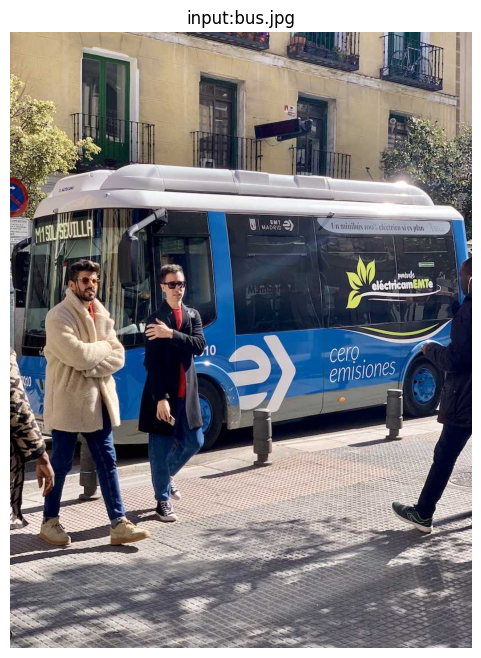

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("bus.jpg")
plt.figure(figsize=(6,8))
plt.imshow(img)
plt.axis("off")
plt.title("input:bus.jpg")
plt.show()

In [25]:
# 셀 1. 감지

model = YOLO("yolo11n.pt") # 모델 크기 라인업: n < s < m < i < x (클수록 정확, 느림)
results = model("bus.jpg")
r = results[0]

# 사전학습(pretraining) : 큰 데이터셋으로 모델을 미리 학습시켜 두는 과정
# 사전학습 모델 (pretraining model): 그 과정을 거쳐 이미 학습이 끝난 모델(가중치) <- yolo11n.pt

# COCO 데이터셋(이미지 33만장 일상 사진들, 80 클래스)으로 사전학습된 모델



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 255.6ms
Speed: 11.9ms preprocess, 255.6ms inference, 4.4ms postprocess per image at shape (1, 3, 640, 480)


In [26]:
# 셀 2. 결과 객체 해부 - boxes 안에 전부 있다
print("\n [결과 해부]")
for box in r.boxes:
  cls_id = int(box.cls)
  name   = r.names[cls_id]
  conf   = float(box.conf)
  xyxy   = box.xyxy[0].tolist()
  print(f" {name:9s} conf {conf:.3f} | xyxy {[round(v) for v in xyxy]}")


 [결과 해부]
 bus       conf 0.940 | xyxy [4, 229, 796, 728]
 person    conf 0.888 | xyxy [671, 395, 810, 879]
 person    conf 0.878 | xyxy [47, 400, 239, 904]
 person    conf 0.856 | xyxy [223, 409, 344, 860]
 person    conf 0.622 | xyxy [0, 556, 69, 872]


In [27]:
 # 셀 3. 사각형 - 박스 그린 사진 저장
 r.save(filename="plot_detected.jpg")

'plot_detected.jpg'

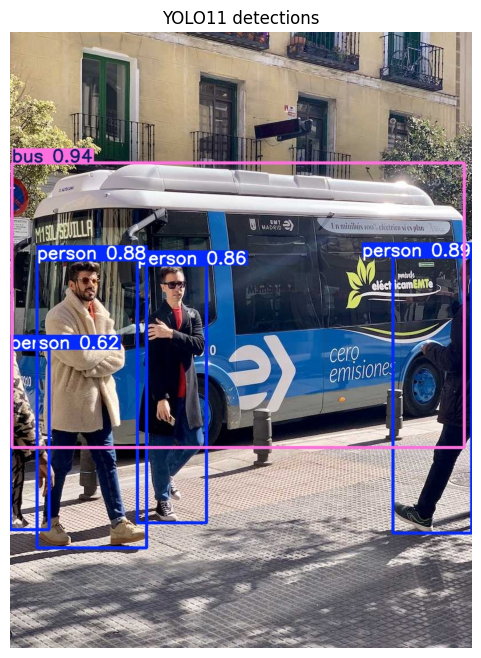

In [28]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("plot_detected.jpg")
plt.figure(figsize=(6,8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO11 detections")
plt.show()

In [29]:
# 셀 4. conf 문턱 조절
for conf_thr in [0.25, 0.6, 0.9]:
  n = len(model("bus.jpg", conf=conf_thr, verbose=False)[0].boxes) # 결과[0].boxes 의 개수를 len()으로 셈, verbose=False: 진행 로그 끔
  print(f"conf ≥ {conf_thr} -> 감지 {n}개 ")
  # 문턱을 올리면 확실한 것만 남는다 (precision ↑up,   recall ↓down )

conf ≥ 0.25 -> 감지 5개 
conf ≥ 0.6 -> 감지 5개 
conf ≥ 0.9 -> 감지 1개 


In [30]:
# 셀 5. '도로위험강지 앱' 형식으로 변환
detections = []
for box in r.boxes:
  x1, y1, x2, y2 = box.xyxyn[0].tolist()
  detections.append({
      "type":r.names[int(box.cls)],
      "confidence":round(float(box.conf), 3),
      "box": {"x1": round(x1, 3), "y1": round(y1, 3), "x2": round(x2, 3), "y2": round(y2, 3)},
  })

  import json
  print(json.dumps(detections[:2], ensure_ascii=False, indent=2)) # json.dumps: 객체를 JSON 문자열로


[
  {
    "type": "bus",
    "confidence": 0.94,
    "box": {
      "x1": 0.005,
      "y1": 0.212,
      "x2": 0.983,
      "y2": 0.674
    }
  }
]
[
  {
    "type": "bus",
    "confidence": 0.94,
    "box": {
      "x1": 0.005,
      "y1": 0.212,
      "x2": 0.983,
      "y2": 0.674
    }
  },
  {
    "type": "person",
    "confidence": 0.888,
    "box": {
      "x1": 0.828,
      "y1": 0.366,
      "x2": 1.0,
      "y2": 0.814
    }
  }
]
[
  {
    "type": "bus",
    "confidence": 0.94,
    "box": {
      "x1": 0.005,
      "y1": 0.212,
      "x2": 0.983,
      "y2": 0.674
    }
  },
  {
    "type": "person",
    "confidence": 0.888,
    "box": {
      "x1": 0.828,
      "y1": 0.366,
      "x2": 1.0,
      "y2": 0.814
    }
  }
]
[
  {
    "type": "bus",
    "confidence": 0.94,
    "box": {
      "x1": 0.005,
      "y1": 0.212,
      "x2": 0.983,
      "y2": 0.674
    }
  },
  {
    "type": "person",
    "confidence": 0.888,
    "box": {
      "x1": 0.828,
      "y1": 0.366,
      "

In [31]:
print(r.boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 0., 0., 0., 0.])
conf: tensor([0.9402, 0.8882, 0.8783, 0.8558, 0.6219])
data: tensor([[3.8327e+00, 2.2936e+02, 7.9619e+02, 7.2841e+02, 9.4015e-01, 5.0000e+00],
        [6.7102e+02, 3.9483e+02, 8.0981e+02, 8.7871e+02, 8.8822e-01, 0.0000e+00],
        [4.7405e+01, 3.9957e+02, 2.3930e+02, 9.0419e+02, 8.7825e-01, 0.0000e+00],
        [2.2306e+02, 4.0869e+02, 3.4447e+02, 8.6044e+02, 8.5577e-01, 0.0000e+00],
        [2.1726e-02, 5.5607e+02, 6.8886e+01, 8.7236e+02, 6.2192e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[400.0136, 478.8883, 792.3619, 499.0480],
        [740.4135, 636.7728, 138.7925, 483.8793],
        [143.3527, 651.8801, 191.8960, 504.6298],
        [283.7633, 634.5623, 121.4087, 451.7471],
        [ 34.4536, 714.2138,  68.8638, 316.2908]])
xywhn: tensor([[0.4938, 0.4434, 0.9782, 0.4621],
        [0.9141, 0.5896, 0.1713, 0.4480],
        [0.17